In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

print("Setup complete")

signal = np.array([0, 0, 0, 5, 5, 5, 0, 0, 0]) # a flat line with a block
edge_finder = np.array([1, -1]) # this pattern reacts to a change

# TODO: slide the edge_finder over the signal using np.convolve
result = np.convolve(signal, edge_finder, mode="valid")

print("signal:", signal)
print("result:", result)

Setup complete
signal: [0 0 0 5 5 5 0 0 0]
result: [ 0  0  5  0  0 -5  0  0]


Number of pictures: 1797 and each is (8, 8)


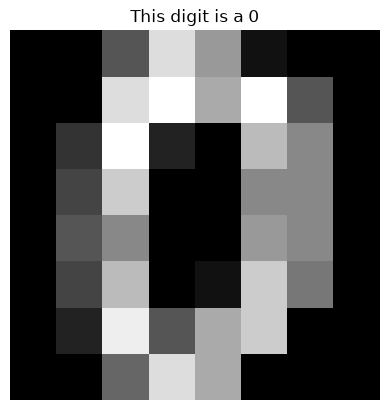

Training pictures: 1437 and test pictures: 360
SmallCNN(
  (conv): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc): Linear(in_features=72, out_features=10, bias=True)
)


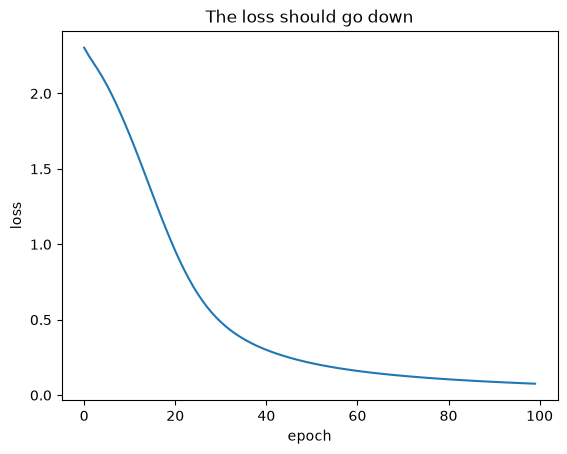

CNN test accuracy: 0.972


In [2]:
digits = load_digits()
print("Number of pictures:", len(digits.images), "and each is", digits.images[0].shape)

# Show the first picture
plt.imshow(digits.images[0], cmap="gray")
plt.title(f"This digit is a {digits.target[0]}")
plt.axis("off")
plt.show()

# Prepare the data: add a colour channel and scale the pixels to the range 0 to 1
X = digits.images[:, None, :, :] / 16.0
y = digits.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.float32)

print("Training pictures:", X_train.shape[0], "and test pictures:", X_test.shape[0])

torch.manual_seed(0)

class SmallCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # TODO: a convolution with 1 input channel, 8 output patterns, and a kernel size of 3
        self.conv = nn.Conv2d(1, 8, kernel_size=3)
        self.pool = nn.MaxPool2d(2) # keeps the strongest value in a 2x2 grid
        self.fc = nn.Linear(8 * 3 * 3, 10) # 10 outputs, one per digit

    def forward(self, x):
        x = torch.relu(self.conv(x))
        x = self.pool(x)
        x = x.flatten(1)
        return self.fc(x)

model = SmallCNN()
print(model)

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# TODO: train for 100 rounds (epochs)
losses = []
for epoch in range(100):
    optimizer.zero_grad()
    loss = loss_fn(model(X_train), y_train)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

plt.plot(losses)
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("The loss should go down")
plt.show()

acc = accuracy_score(y_test, model(X_test).argmax(1).numpy())
print("CNN test accuracy:", round(acc, 3))

In [4]:
def tokenizer(sentence):
    # TODO: make the sentence lower case, then split it into a list of words
    return sentence.lower().split()

sentence = "The cat sat on the mat"
tokens = tokenizer(sentence)

print("Tokens:", tokens)
print("Number of tokens:", len(tokens))

Tokens: ['the', 'cat', 'sat', 'on', 'the', 'mat']
Number of tokens: 6


In [5]:
a = tokenizer("dog bites man")
b = tokenizer("man bites dog")

print("Sentence A tokens:", a)
print("Sentence B tokens:", b)

# TODO: check whether the two sentences use the same set of words (ignore the order)
same_words = sorted(a) == sorted(b)

print("Same words?", same_words)
print("Same order?", a == b)

Sentence A tokens: ['dog', 'bites', 'man']
Sentence B tokens: ['man', 'bites', 'dog']
Same words? True
Same order? False


In [6]:
a = tokenizer("dog bites man")
b = tokenizer("man bites dog")

print("Sentence A tokens:", a)
print("Sentence B tokens:", b)

# TODO: check whether the two sentences use the same set of words (ignore the order)
same_words = sorted(a) == sorted(b)

print("Same words?", same_words)
print("Same order?", a == b)

Sentence A tokens: ['dog', 'bites', 'man']
Sentence B tokens: ['man', 'bites', 'dog']
Same words? True
Same order? False


In [7]:
def softmax(z):
    e = np.exp(z - z.max(axis=-1, keepdims=True))
    return e / e.sum(axis=-1, keepdims=True)

np.random.seed(0)

# Three tokens, each described by 4 numbers.
Q = np.random.randn(3, 4)
K = np.random.randn(3, 4)
V = np.random.randn(3, 4)

d_k = Q.shape[-1] # the size of each token vector, here 4

# TODO: divide the scores by the square root of d_k (this is the "scaled" part)
scores = Q @ K.T / np.sqrt(d_k)
weights = softmax(scores) # turn scores into attention weights that add up to 1
output = weights @ V # mix the values using the weights

print("Attention weights (each row adds up to 1):")
print(weights.round(2))

# Repaired print statement:
print("\nOutput (the mixed values):")
print(output.round(2))

Attention weights (each row adds up to 1):
[[0.68 0.3  0.02]
 [0.29 0.7  0.01]
 [0.5  0.19 0.31]]

Output (the mixed values):
[[ 2.   -0.58  0.07 -0.01]
 [ 1.71  0.57  0.12  0.21]
 [ 1.15 -1.07 -0.06  0.03]]


In [1]:
import numpy as np

signal = np.array([0, 0, 0, 5, 5, 5, 0, 0, 0])
smoothing_filter = np.array([1, 1, 1]) / 3

smoothed_result = np.convolve(signal, smoothing_filter, mode="valid")

print("Original signal:", signal)
print("Smoothed result: ", smoothed_result)

Original signal: [0 0 0 5 5 5 0 0 0]
Smoothed result:  [0.         1.66666667 3.33333333 5.         3.33333333 1.66666667
 0.        ]


In [2]:
import re

def advanced_tokenizer(sentence):
    # Regex pattern finds words (\w+) or punctuation ([^\w\s])
    return re.findall(r'\w+|[^\w\s]', sentence.lower())

sentence = "The cat sat on the mat."
tokens = advanced_tokenizer(sentence)
print("Advanced Tokens:", tokens)

Advanced Tokens: ['the', 'cat', 'sat', 'on', 'the', 'mat', '.']
